In [2]:
# ============================================
# IRIS FLOWER CLASSIFICATION
# Étape 1 : Chargement des données
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement direct depuis scikit-learn (pas besoin de CSV !)
from sklearn.datasets import load_iris

# Charger le dataset
iris = load_iris()

# Convertir en DataFrame pandas
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Remplacer 0,1,2 par les vrais noms
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor', 
    2: 'virginica'
})

# Afficher les 5 premières lignes
print("✅ Dataset chargé avec succès !")
print(f"📊 Taille du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\n--- Aperçu des données ---")
df.head(10)

✅ Dataset chargé avec succès !
📊 Taille du dataset : 150 lignes, 5 colonnes

--- Aperçu des données ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
# ============================================
# Étape 2 : Exploration des données (EDA)
# ============================================

print("=" * 50)
print("📋 INFORMATIONS GÉNÉRALES")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("📊 STATISTIQUES DE BASE")
print("=" * 50)
df.describe()

📋 INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

📊 STATISTIQUES DE BASE


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
print("=" * 50)
print("❓ VALEURS MANQUANTES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("🌸 DISTRIBUTION DES ESPÈCES")
print("=" * 50)
print(df['species'].value_counts())

❓ VALEURS MANQUANTES
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

🌸 DISTRIBUTION DES ESPÈCES
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_2044\287450964.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='species',
C:\Users\hp\AppData\Local\Temp\ipykernel_2044\287450964.py:16: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


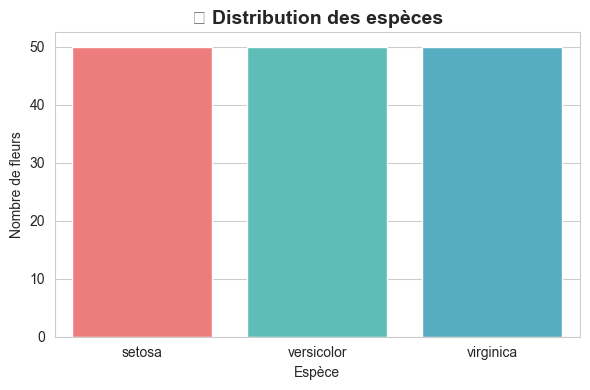

In [5]:
# ============================================
# Étape 3 : Visualisation des données
# ============================================

# Style général
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# --- Graphique 1 : Distribution des espèces ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='species', 
              palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('🌸 Distribution des espèces', fontsize=14, fontweight='bold')
plt.xlabel('Espèce')
plt.ylabel('Nombre de fleurs')
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_2044\2168685516.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


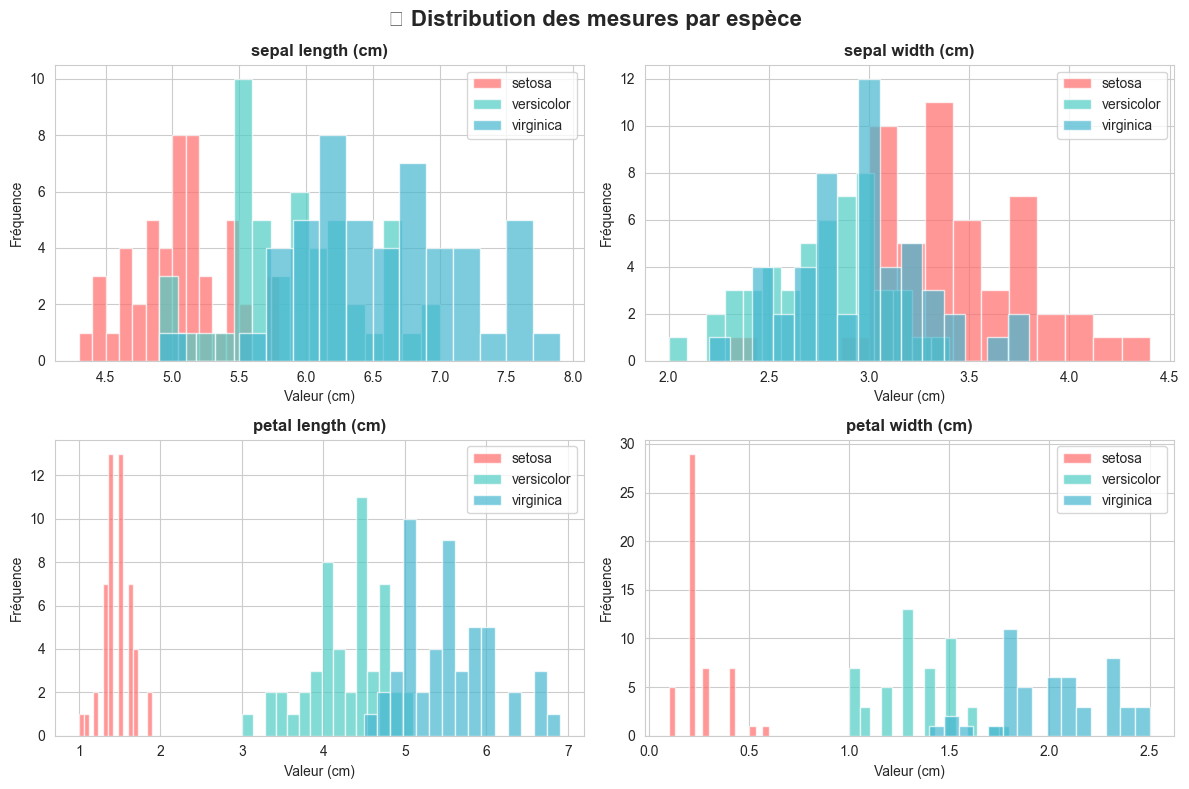

In [6]:
# --- Graphique 2 : Histogrammes des 4 features ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('📊 Distribution des mesures par espèce', 
             fontsize=16, fontweight='bold')

features = ['sepal length (cm)', 'sepal width (cm)', 
            'petal length (cm)', 'petal width (cm)']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, feature in enumerate(features):
    ax = axes[i//2, i%2]
    for j, species in enumerate(['setosa', 'versicolor', 'virginica']):
        subset = df[df['species'] == species]
        ax.hist(subset[feature], alpha=0.7, 
                label=species, color=colors[j], bins=15)
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Valeur (cm)')
    ax.set_ylabel('Fréquence')
    ax.legend()

plt.tight_layout()
plt.show()

⏳ Génération du pairplot...


C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


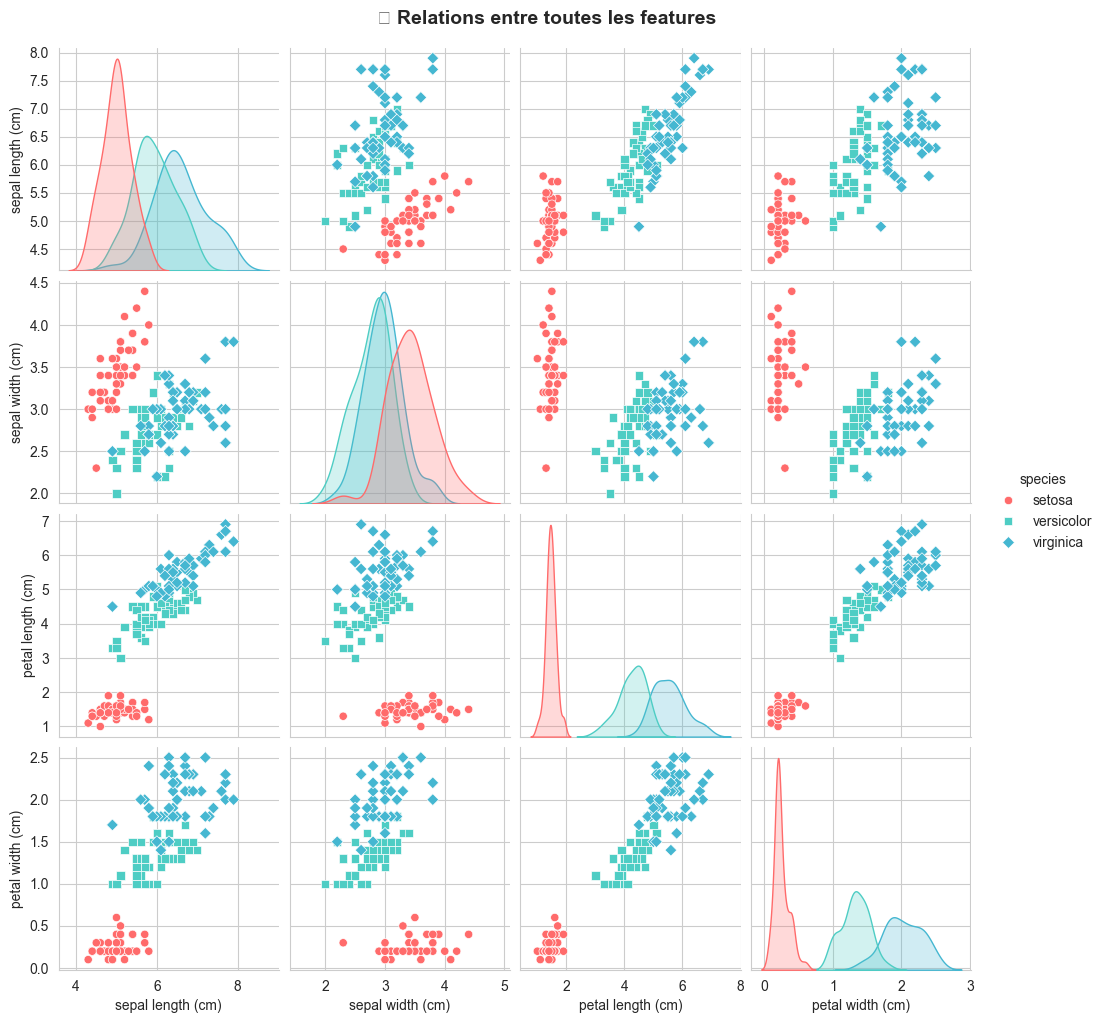

✅ Visualisation terminée !


In [7]:
# --- Graphique 3 : Pairplot (le plus important !) ---
print("⏳ Génération du pairplot...")
sns.pairplot(df, hue='species', 
             palette={'setosa': '#FF6B6B', 
                      'versicolor': '#4ECDC4', 
                      'virginica': '#45B7D1'},
             markers=['o', 's', 'D'])
plt.suptitle('🔍 Relations entre toutes les features', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()
print("✅ Visualisation terminée !")

In [8]:
# ============================================
# Étape 4 : Préparation des données
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Séparer features (X) et target (y)
X = df[['sepal length (cm)', 'sepal width (cm)', 
        'petal length (cm)', 'petal width (cm)']]
y = df['species']

# Split : 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Données préparées !")
print(f"📚 Entraînement : {X_train.shape[0]} fleurs")
print(f"🧪 Test         : {X_test.shape[0]} fleurs")

✅ Données préparées !
📚 Entraînement : 120 fleurs
🧪 Test         : 30 fleurs


In [9]:
# ============================================
# Étape 5 : Entraînement des 3 modèles
# ============================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Définir les 3 modèles
modeles = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Entraîner et évaluer chaque modèle
resultats = {}

print("🚀 Entraînement des modèles...\n")

for nom, modele in modeles.items():
    # Entraînement
    modele.fit(X_train, y_train)
    
    # Prédiction
    y_pred = modele.predict(X_test)
    
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    resultats[nom] = accuracy
    
    print(f"✅ {nom:15} → Accuracy : {accuracy*100:.2f}%")

print("\n🏆 Meilleur modèle :", max(resultats, key=resultats.get))

🚀 Entraînement des modèles...

✅ KNN             → Accuracy : 100.00%
✅ Decision Tree   → Accuracy : 100.00%
✅ Random Forest   → Accuracy : 100.00%

🏆 Meilleur modèle : KNN


In [10]:
# ============================================
# Étape 6 : Évaluation détaillée
# ============================================

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# On utilise Random Forest comme modèle final
modele_final = modeles['Random Forest']
y_pred = modele_final.predict(X_test)

# --- Rapport détaillé ---
print("=" * 55)
print("📋 RAPPORT DE CLASSIFICATION - Random Forest")
print("=" * 55)
print(classification_report(y_test, y_pred))

📋 RAPPORT DE CLASSIFICATION - Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



C:\Users\hp\AppData\Local\Temp\ipykernel_2044\3981490749.py:15: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


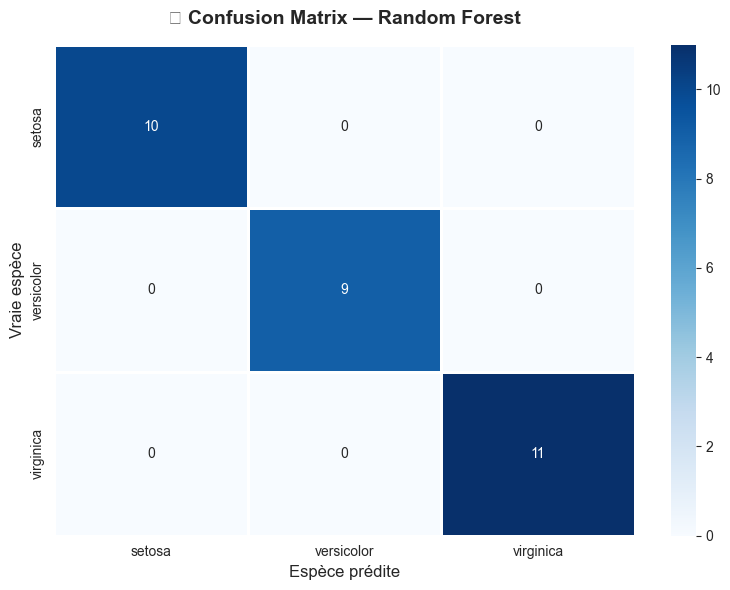

In [11]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred, 
                      labels=['setosa', 'versicolor', 'virginica'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'],
            linewidths=2, linecolor='white')

plt.title('🎯 Confusion Matrix — Random Forest', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Vraie espèce', fontsize=12)
plt.xlabel('Espèce prédite', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_2044\313742009.py:21: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


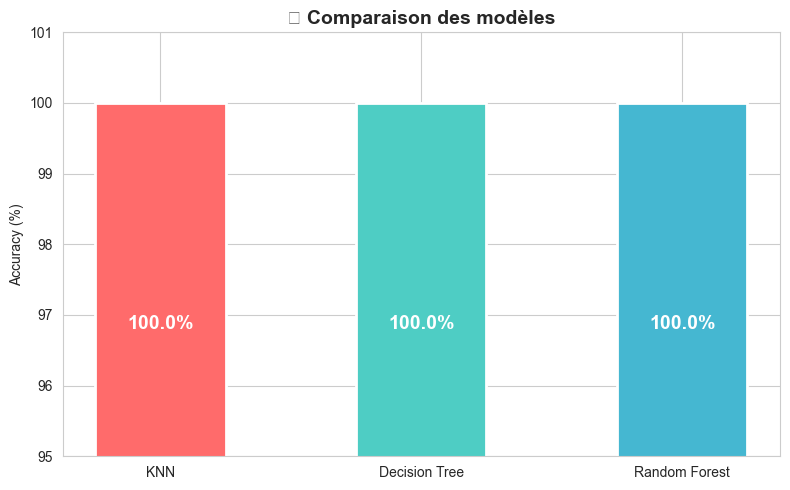

In [12]:
# --- Comparaison des modèles en graphique ---
plt.figure(figsize=(8, 5))
noms = list(resultats.keys())
accuracies = [v * 100 for v in resultats.values()]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(noms, accuracies, color=colors, 
               width=0.5, edgecolor='white', linewidth=2)

# Ajouter les valeurs sur les barres
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() - 3,
             f'{acc:.1f}%', ha='center', va='top',
             fontsize=14, fontweight='bold', color='white')

plt.title('🏆 Comparaison des modèles', 
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(95, 101)
plt.tight_layout()
plt.show()

In [13]:
# ============================================
# Étape 7 : Prédiction sur de nouvelles fleurs
# ============================================

import numpy as np

def predire_fleur(sepal_length, sepal_width, petal_length, petal_width):
    """
    Prédit l'espèce d'une fleur iris à partir de ses mesures
    """
    mesures = np.array([[sepal_length, sepal_width, 
                         petal_length, petal_width]])
    
    prediction = modele_final.predict(mesures)[0]
    proba = modele_final.predict_proba(mesures)[0]
    
    especes = modele_final.classes_
    
    print("=" * 45)
    print("🌸 RÉSULTAT DE LA PRÉDICTION")
    print("=" * 45)
    print(f"📏 Mesures entrées :")
    print(f"   Sepal Length : {sepal_length} cm")
    print(f"   Sepal Width  : {sepal_width} cm")
    print(f"   Petal Length : {petal_length} cm")
    print(f"   Petal Width  : {petal_width} cm")
    print("-" * 45)
    print(f"🏷️  Espèce prédite : {prediction.upper()}")
    print("-" * 45)
    print("📊 Probabilités :")
    for espece, prob in zip(especes, proba):
        barre = "█" * int(prob * 20)
        print(f"   {espece:12} : {barre} {prob*100:.1f}%")
    print("=" * 45)

# --- Test avec 3 fleurs différentes ---

print("🌺 TEST 1 — Fleur typique Setosa")
predire_fleur(5.1, 3.5, 1.4, 0.2)

print("\n🌺 TEST 2 — Fleur typique Versicolor")
predire_fleur(6.0, 2.9, 4.5, 1.5)

print("\n🌺 TEST 3 — Fleur typique Virginica")
predire_fleur(6.5, 3.0, 5.5, 2.0)

🌺 TEST 1 — Fleur typique Setosa
🌸 RÉSULTAT DE LA PRÉDICTION
📏 Mesures entrées :
   Sepal Length : 5.1 cm
   Sepal Width  : 3.5 cm
   Petal Length : 1.4 cm
   Petal Width  : 0.2 cm
---------------------------------------------
🏷️  Espèce prédite : SETOSA
---------------------------------------------
📊 Probabilités :
   setosa       : ████████████████████ 100.0%
   versicolor   :  0.0%
   virginica    :  0.0%

🌺 TEST 2 — Fleur typique Versicolor
🌸 RÉSULTAT DE LA PRÉDICTION
📏 Mesures entrées :
   Sepal Length : 6.0 cm
   Sepal Width  : 2.9 cm
   Petal Length : 4.5 cm
   Petal Width  : 1.5 cm
---------------------------------------------
🏷️  Espèce prédite : VERSICOLOR
---------------------------------------------
📊 Probabilités :
   setosa       :  0.0%
   versicolor   : ████████████████████ 100.0%
   virginica    :  0.0%

🌺 TEST 3 — Fleur typique Virginica
🌸 RÉSULTAT DE LA PRÉDICTION
📏 Mesures entrées :
   Sepal Length : 6.5 cm
   Sepal Width  : 3.0 cm
   Petal Length : 5.5 cm
   Petal W

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\vali

C:\Users\hp\AppData\Local\Temp\ipykernel_2044\2882320806.py:29: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


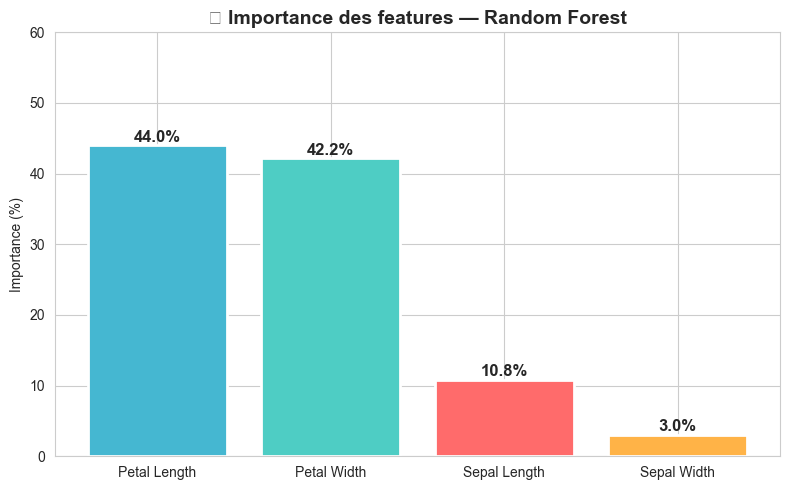


💡 Conclusion :
   La feature la plus importante est : Petal Length
   La feature la moins importante est : Sepal Width


In [14]:
# ============================================
# BONUS : Importance des features
# ============================================

importances = modele_final.feature_importances_
features = ['Sepal Length', 'Sepal Width', 
            'Petal Length', 'Petal Width']

# Trier par importance
indices = np.argsort(importances)[::-1]
features_triees = [features[i] for i in indices]
importances_triees = importances[indices]

plt.figure(figsize=(8, 5))
colors = ['#45B7D1', '#4ECDC4', '#FF6B6B', '#FFB347']
bars = plt.bar(features_triees, importances_triees * 100,
               color=colors, edgecolor='white', linewidth=2)

for bar, imp in zip(bars, importances_triees):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{imp*100:.1f}%', ha='center',
             fontsize=12, fontweight='bold')

plt.title('🔑 Importance des features — Random Forest',
          fontsize=14, fontweight='bold')
plt.ylabel('Importance (%)')
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

print("\n💡 Conclusion :")
print(f"   La feature la plus importante est : {features_triees[0]}")
print(f"   La feature la moins importante est : {features_triees[-1]}")